In [1]:
# Imports and Environment Setup
import pandas as pd
import numpy as np
from statsbombpy import sb
import time
import warnings
from scipy.spatial import ConvexHull

warnings.filterwarnings('ignore')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
# Cell 2: Extraction and Era Categorization
from statsbombpy import sb

def assign_manager_era(date_string):
    """Categorizes matches into tactical eras based on historical dates."""
    match_date = pd.to_datetime(date_string)
    if match_date < pd.to_datetime('2008-06-30'): return 'Rijkaard'
    elif match_date < pd.to_datetime('2012-06-30'): return 'Guardiola'
    elif match_date < pd.to_datetime('2014-06-30'): return 'Vilanova/Martino'
    elif match_date < pd.to_datetime('2017-06-30'): return 'Luis Enrique'
    elif match_date < pd.to_datetime('2020-01-13'): return 'Valverde'
    elif match_date < pd.to_datetime('2021-11-06'): return 'Setien/Koeman'
    else: return 'Xavi'

print("Starting Data Extraction...")

comps = sb.competitions()
la_liga_df = comps[comps['competition_id'] == 11]

# Exclude 1973/1974 and 2004/2005 due to tiny sample sizes
seasons_to_exclude = [278, 37, 38]
la_liga_seasons = la_liga_df[~la_liga_df['season_id'].isin(seasons_to_exclude)]['season_id'].tolist()

all_events = []
total_matches = 0

for season in la_liga_seasons:
    try:
        matches = sb.matches(competition_id=11, season_id=season)
        barca_matches = matches[(matches['home_team'] == 'Barcelona') | (matches['away_team'] == 'Barcelona')]
        
        print(f"Season ID {season}: Downloading {len(barca_matches)} Barcelona matches...")
        
        for _, match in barca_matches.iterrows():
            match_id = match['match_id']
            success = False
            retries = 3
            
            # RETRY LOGIC: Try up to 3 times per match if the API drops the connection
            for attempt in range(retries):
                try:
                    events = sb.events(match_id=match_id)
                    
                    # Attach our custom variables
                    events['season_id'] = season
                    events['match_id'] = match_id
                    events['match_date'] = match['match_date']
                    events['manager_era'] = assign_manager_era(match['match_date'])
                    
                    all_events.append(events)
                    total_matches += 1
                    success = True
                    
                    time.sleep(0.5)
                    break # Break out of the retry loop and go to the next match
                    
                except Exception as e:
                    print(f"Timeout on match {match_id}. Retrying... (Attempt {attempt+1}/{retries})")
                    time.sleep(5) # Wait 5 seconds before trying again
            
            if not success:
                print(f"FATAL: Could not download match {match_id} after {retries} attempts.")
                
    except Exception as e:
        print(f"Could not load schedule for season {season}: {e}")

# Combine all seasons into one massive table
raw_df = pd.concat(all_events, ignore_index=True)

# Save to your computer
raw_df.to_pickle("barca_raw_events.pkl")
print(f"\nEXTRACTION COMPLETE! Saved {len(raw_df)} total events to 'barca_raw_events.pkl'.")

Starting Data Extraction...
Season ID 90: Downloading 35 Barcelona matches...
Season ID 42: Downloading 33 Barcelona matches...
Season ID 4: Downloading 34 Barcelona matches...
Season ID 1: Downloading 36 Barcelona matches...
Season ID 2: Downloading 34 Barcelona matches...
Season ID 27: Downloading 38 Barcelona matches...
Season ID 26: Downloading 38 Barcelona matches...
Season ID 25: Downloading 31 Barcelona matches...
Season ID 24: Downloading 32 Barcelona matches...
Season ID 23: Downloading 37 Barcelona matches...
Season ID 22: Downloading 33 Barcelona matches...
Season ID 21: Downloading 35 Barcelona matches...
Season ID 41: Downloading 31 Barcelona matches...
Season ID 40: Downloading 28 Barcelona matches...
Season ID 39: Downloading 26 Barcelona matches...

EXTRACTION COMPLETE! Saved 1896905 total events to 'barca_raw_events.pkl'.


In [13]:
# Cell 3: Parsing Spatial Coordinates

print("Cleaning nested spatial coordinates...")

# Load the dataset
df = pd.read_pickle("barca_raw_events.pkl")

# Define a function to split the [X, Y] list safely
def extract_coords(loc_list):
    # Check if the data is actually a list with at least 2 numbers
    if isinstance(loc_list, list) and len(loc_list) >= 2:
        return pd.Series([loc_list[0], loc_list[1]])
    # If the event doesn't have a location (like a substitution), leave it blank (NaN)
    return pd.Series([np.nan, np.nan])

# Apply the function to the starting locations of all events
df[['location_x', 'location_y']] = df['location'].apply(extract_coords)

# Apply the function to the ending locations (specifically for passes)
if 'pass_end_location' in df.columns:
    df[['pass_end_location_x', 'pass_end_location_y']] = df['pass_end_location'].apply(extract_coords)

# Save this cleaned version so we don't have to parse it again
df.to_pickle("barca_master_cleaned.pkl")
print(f"SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.")

Cleaning nested spatial coordinates...
SPATIAL PARSING COMPLETE! Saved clean geometry to 'barca_master_cleaned.pkl'.


In [3]:
# Cell 4: Multivariate Feature Engineering
import pandas as pd
import numpy as np
from scipy.spatial import ConvexHull

# --- NEW FUNCTION FOR COMPACTNESS ---
def get_hull_area(x_coords, y_coords):
    """Calculates the geometric area of the team's shape"""
    valid_coords = pd.DataFrame({'x': x_coords, 'y': y_coords}).dropna()
    points = valid_coords.values
    if len(points) >= 3: 
        try:
            hull = ConvexHull(points)
            return hull.volume # In scipy 2D, .volume is the Area
        except:
            return np.nan 
    return np.nan
# ------------------------------------

print("Engineering Extended Tactical Variables...")

# 1. Load the master dataset
df = pd.read_pickle("barca_master_cleaned.pkl")

# Create an empty list to store our match-by-match statistics
match_stats = []

# 2. Loop through every single match to calculate the variables
for match_id, match_data in df.groupby('match_id'):
    
    # Basic match metadata
    season_id = match_data['season_id'].iloc[0]
    manager_era = match_data['manager_era'].iloc[0]
    match_date = match_data['match_date'].iloc[0] if 'match_date' in match_data.columns else season_id
    
    # --- VARIABLE 1 & 2: Defensive Line & High Turnover % ---
    def_events = ['Pressure', 'Tackle', 'Interception', 'Block', 'Ball Recovery']
    barca_def = match_data[(match_data['team'] == 'Barcelona') & (match_data['type'].isin(def_events))]
    
    def_line = barca_def['location_x'].mean() if not barca_def.empty else np.nan
    
    total_def_actions = len(barca_def)
    high_turnovers = len(barca_def[barca_def['location_x'] >= 80])
    
    # Normalize to percentage
    if total_def_actions > 0:
        high_turnover_pct = (high_turnovers / total_def_actions) * 100
    else:
        high_turnover_pct = 0.0
    
    # --- VARIABLE 3: PPDA (Passes Per Defensive Action) ---
    opp_passes = len(match_data[(match_data['team'] != 'Barcelona') & (match_data['type'] == 'Pass')])
    barca_def_ppda = len(barca_def[barca_def['location_x'] > 40]) 
    ppda = opp_passes / barca_def_ppda if barca_def_ppda > 0 else np.nan
    
    # --- VARIABLE 4: xGA (Expected Goals Against) ---
    if 'shot_statsbomb_xg' in match_data.columns:
        opp_shots = match_data[(match_data['team'] != 'Barcelona') & (match_data['type'] == 'Shot')]
        xga = opp_shots['shot_statsbomb_xg'].sum()
    else:
        xga = 0.0 
        
    # --- VARIABLE 5: Total Successful Passes (Tiki-Taka dominance) ---
    barca_passes = len(match_data[
        (match_data['team'] == 'Barcelona') & 
        (match_data['type'] == 'Pass') & 
        (match_data['pass_outcome'].isna())
    ])
    
    # --- NEW VARIABLE 6: Convex Hull Area (Compactness) ---
    # Get all X, Y coordinates for Barcelona in this match using your pre-cleaned columns
    barca_actions = match_data[match_data['team'] == 'Barcelona']
    x_coords = barca_actions['location_x'].tolist()
    y_coords = barca_actions['location_y'].tolist()
    
    compactness_area = get_hull_area(x_coords, y_coords)
    
    # Append to our list
    match_stats.append({
        'match_id': match_id,
        'match_date': match_date,
        'season_id': season_id,
        'manager_era': manager_era,
        'defensive_line': def_line,
        'ppda': ppda,
        'xga': xga,
        'successful_passes': barca_passes,
        'high_turnover_pct': high_turnover_pct,
        'convex_hull_area': compactness_area  # <--- Added for Regression
    })

# 3. Convert to DataFrame and sort chronologically
stats_df = pd.DataFrame(match_stats)
stats_df['match_date'] = pd.to_datetime(stats_df['match_date'])
stats_df = stats_df.sort_values('match_date').reset_index(drop=True)

# 4. Calculate Rolling Averages (10-game window)
rolling_window = 10
stats_df['def_line_rolling'] = stats_df['defensive_line'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['ppda_rolling'] = stats_df['ppda'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['xga_rolling'] = stats_df['xga'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['passes_rolling'] = stats_df['successful_passes'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['high_turnover_pct_rolling'] = stats_df['high_turnover_pct'].rolling(window=rolling_window, min_periods=1).mean()
stats_df['convex_hull_area_rolling'] = stats_df['convex_hull_area'].rolling(window=rolling_window, min_periods=1).mean()

# Drop rows where StatsBomb might have missing data
stats_df = stats_df.dropna()

# 5. Save the final features dataset
stats_df.to_pickle("barca_tactical_features.pkl")
# Also save as CSV for the Machine Learning model later
stats_df.to_csv("barca_tactical_regression_data.csv", index=False)

print("Multivariate Feature Engineering Complete! Saved final CSV for Regression.")

Engineering Extended Tactical Variables...
Multivariate Feature Engineering Complete! Saved final CSV for Regression.


In [4]:
# Cell 5: Statistical Significance Testing (Independent T-Test)
import pandas as pd
from scipy import stats

print("Running Independent T-Tests (Guardiola vs Valverde)...\n")

# 1. Load the features dataset
try:
    stats_df = pd.read_pickle("barca_tactical_features.pkl")
except FileNotFoundError:
    print("Error: Run the Feature Engineering cell first!")

# 2. Filter data for JUST Guardiola and Valverde for direct comparison
filtered_df = stats_df[stats_df['manager_era'].isin(['Guardiola', 'Valverde'])].dropna()

# 3. Define the metrics to test (UPDATED)
metrics = {
    'Defensive Line (Avg X-Coordinate)': 'defensive_line',
    'PPDA (Pressing)': 'ppda',
    'Total Successful Passes': 'successful_passes',
    'High Turnover %': 'high_turnover_pct',
    'Convex Hull Area (Spatial Compactness)': 'convex_hull_area',
    'xGA (Expected Goals Against)': 'xga'
}

# 4. Run Welch's T-Test for each metric
for metric_name, column in metrics.items():
    # Extract arrays for each era
    group_pep = filtered_df[filtered_df['manager_era'] == 'Guardiola'][column]
    group_valverde = filtered_df[filtered_df['manager_era'] == 'Valverde'][column]
    
    # Run Independent T-Test
    t_stat, p_value = stats.ttest_ind(group_pep, group_valverde, equal_var=False)
    
    # Formatting the output cleanly
    print(f"--- {metric_name} ---")
    print(f"  Guardiola Avg: {group_pep.mean():.2f}")
    print(f"  Valverde Avg:  {group_valverde.mean():.2f}")
    
    if p_value < 0.05:
        print(f"  Result: SIGNIFICANT (p = {p_value:.5f})\n")
    else:
        print(f"  Result: NOT SIGNIFICANT (p = {p_value:.5f})\n")

print("Thesis translation: The T-Test proves whether the direct drop-off between Guardiola and Valverde was mathematically significant.")

Running Independent T-Tests (Guardiola vs Valverde)...

--- Defensive Line (Avg X-Coordinate) ---
  Guardiola Avg: 56.97
  Valverde Avg:  56.65
  Result: NOT SIGNIFICANT (p = 0.65892)

--- PPDA (Pressing) ---
  Guardiola Avg: 2.52
  Valverde Avg:  2.94
  Result: SIGNIFICANT (p = 0.00014)

--- Total Successful Passes ---
  Guardiola Avg: 611.10
  Valverde Avg:  600.82
  Result: NOT SIGNIFICANT (p = 0.50696)

--- High Turnover % ---
  Guardiola Avg: 22.68
  Valverde Avg:  24.58
  Result: SIGNIFICANT (p = 0.02674)

--- Convex Hull Area (Spatial Compactness) ---
  Guardiola Avg: 9166.85
  Valverde Avg:  9211.21
  Result: SIGNIFICANT (p = 0.02485)

--- xGA (Expected Goals Against) ---
  Guardiola Avg: 0.71
  Valverde Avg:  0.98
  Result: SIGNIFICANT (p = 0.00098)

Thesis translation: The T-Test proves whether the direct drop-off between Guardiola and Valverde was mathematically significant.


Generating 6-Panel Tactical Dashboard...


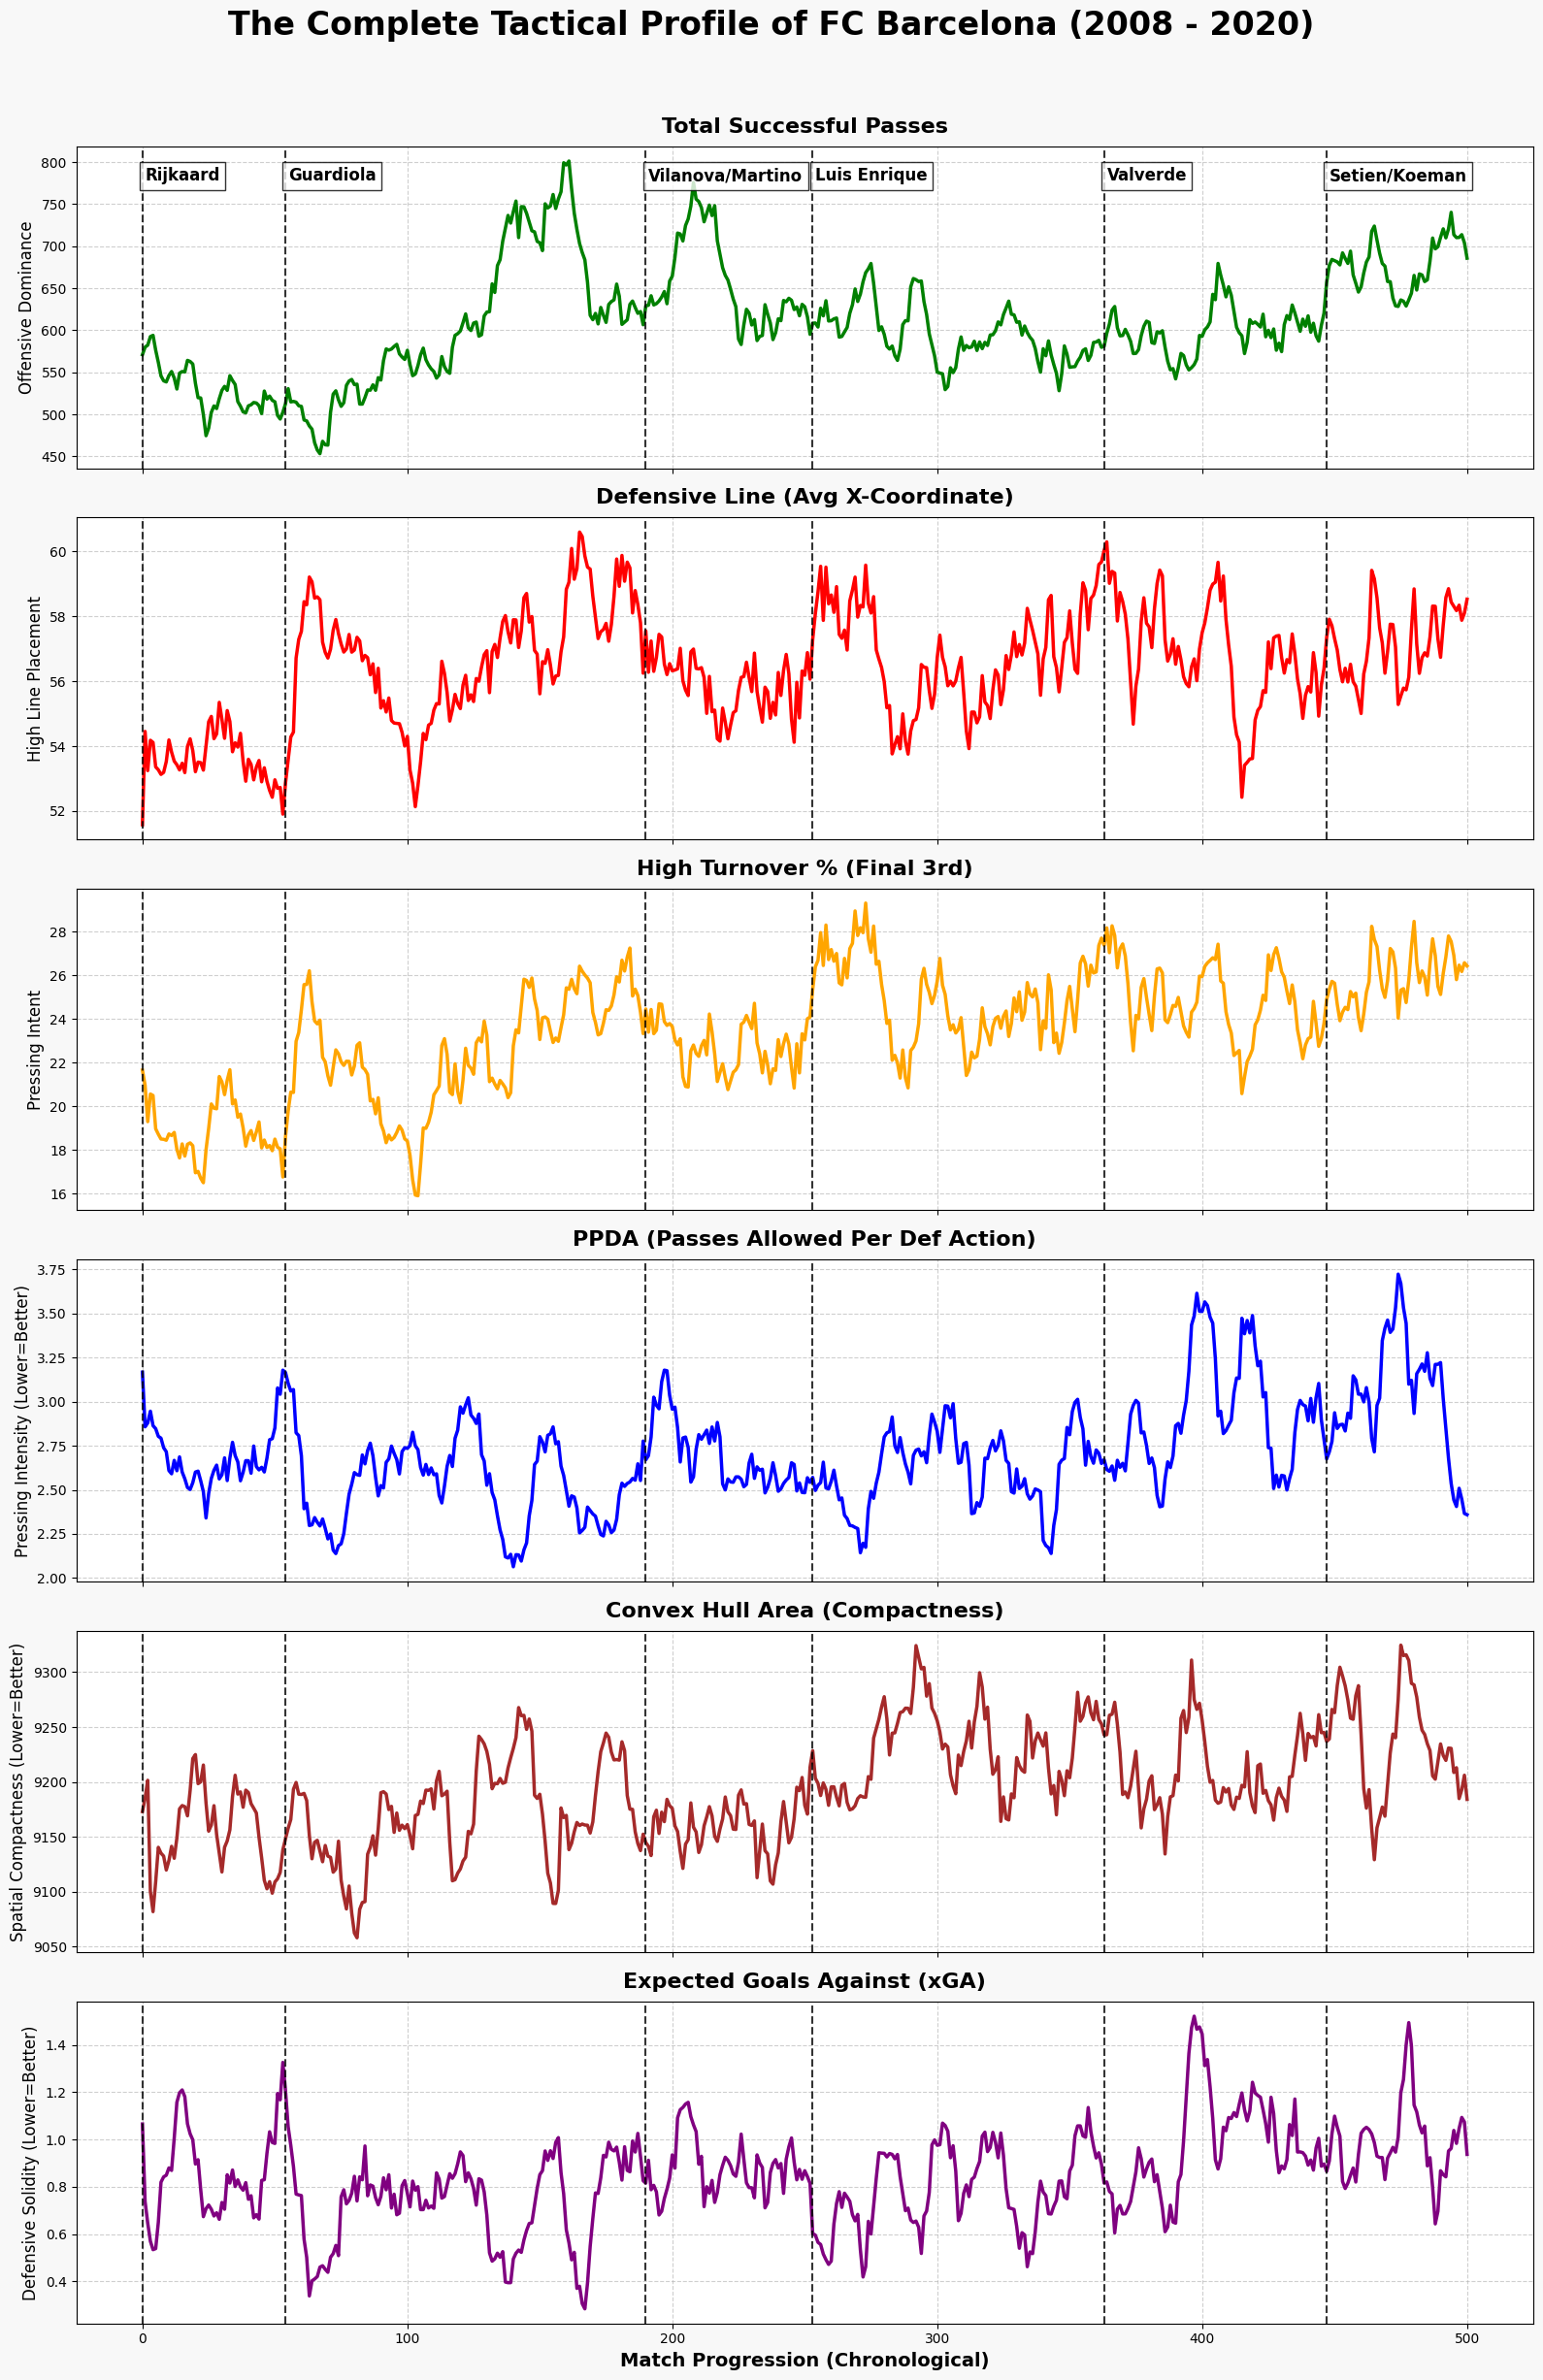

Multivariate Dashboard generated and saved!


In [5]:
# Cell 6: The Capstone Multivariate Tactical Dashboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating 6-Panel Tactical Dashboard...")

# 1. Load the engineered features
stats_df = pd.read_pickle("barca_tactical_features.pkl")

# Drop any rows where metrics failed to calculate to keep the lines clean
stats_df = stats_df.dropna(subset=['def_line_rolling', 'ppda_rolling', 'convex_hull_area_rolling'])

# 2. Setup the 6-Panel Plot
fig, axes = plt.subplots(6, 1, figsize=(16, 24), sharex=True)
fig.patch.set_facecolor('#f8f8f8')

# 3. Define the metrics we want to plot (UPDATED)
metrics = [
    ('passes_rolling', 'Total Successful Passes', 'green', 'Offensive Dominance'),
    ('def_line_rolling', 'Defensive Line (Avg X-Coordinate)', 'red', 'High Line Placement'),
    ('high_turnover_pct_rolling', 'High Turnover % (Final 3rd)', 'orange', 'Pressing Intent'),
    ('ppda_rolling', 'PPDA (Passes Allowed Per Def Action)', 'blue', 'Pressing Intensity (Lower=Better)'),
    ('convex_hull_area_rolling', 'Convex Hull Area (Compactness)', 'brown', 'Spatial Compactness (Lower=Better)'),
    ('xga_rolling', 'Expected Goals Against (xGA)', 'purple', 'Defensive Solidity (Lower=Better)')
]

# 4. Plot each metric
for i, (col, title, color, ylabel) in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=stats_df, x=stats_df.index, y=col, ax=ax, color=color, linewidth=2.5)
    
    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_facecolor('#ffffff')

# 5. Add vertical lines for Manager Eras across all subplots
era_changes = stats_df.drop_duplicates(subset=['manager_era'], keep='first')
for i in range(len(axes)):
    for idx, row in era_changes.iterrows():
        axes[i].axvline(x=idx, color='black', linestyle='--', alpha=0.8, linewidth=1.5)
        # Add the text labels to the top plot to avoid clutter
        if i == 0:
            axes[i].text(idx + 1, axes[i].get_ylim()[1] * 0.95, row['manager_era'], 
                         rotation=0, fontsize=12, fontweight='bold', 
                         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# 6. Final Polish
axes[-1].set_xlabel("Match Progression (Chronological)", fontsize=14, fontweight='bold')
plt.suptitle("The Complete Tactical Profile of FC Barcelona (2008 - 2020)", 
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()

# Save for your thesis
plt.savefig("Thesis_Fig_Multivariate_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

print("Multivariate Dashboard generated and saved!")

Generating Baseline-Controlled Heatmaps...


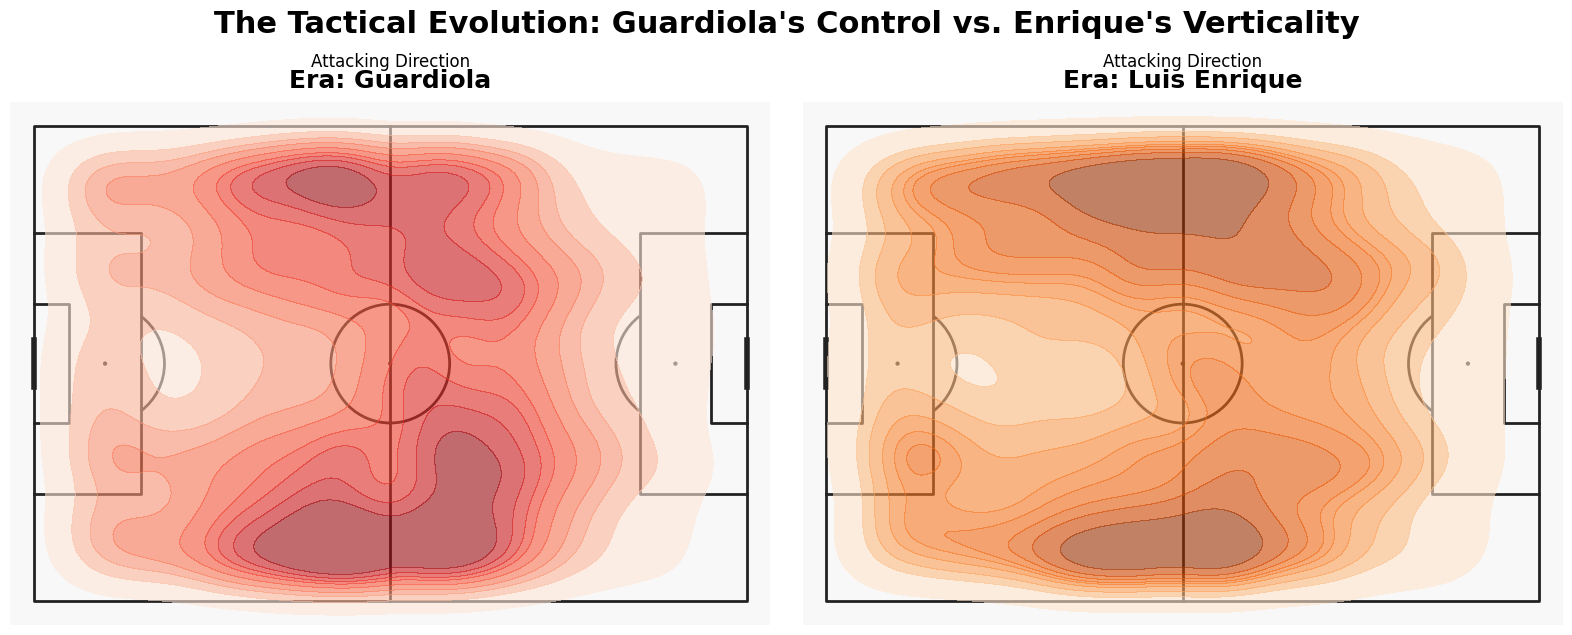

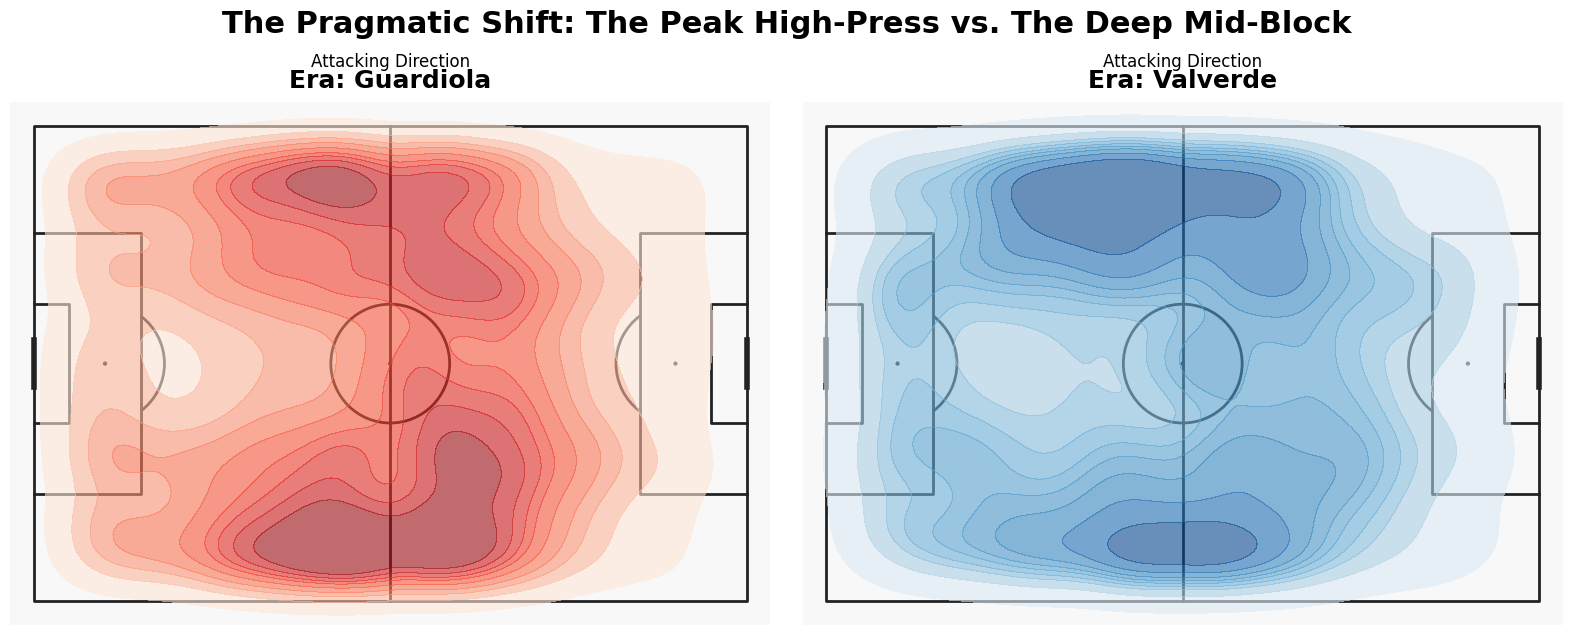

Heatmaps generated and saved!


In [ ]:
# Cell 7: The "Constant Baseline" Capstone Heatmaps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

print("Generating Baseline-Controlled Heatmaps...")

# 1. Load and filter the master data
df = pd.read_pickle("barca_master_cleaned.pkl")
def_events = ['Pressure', 'Tackle', 'Interception', 'Block', 'Ball Recovery']
df_def = df[(df['team'] == 'Barcelona') & (df['type'].isin(def_events))].copy()
df_def = df_def.dropna(subset=['location_x', 'location_y'])

# Helper function to plot a 1x2 comparison
def plot_head_to_head(manager1, manager2, color1, color2, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f8f8f8', line_color='#222222')
    
    managers = [manager1, manager2]
    colors = [color1, color2]
    
    for i, manager in enumerate(managers):
        manager_data = df_def[df_def['manager_era'] == manager]
        pitch.draw(ax=axes[i])
        
        if not manager_data.empty:
            sns.kdeplot(
                x=manager_data['location_x'], y=manager_data['location_y'], 
                ax=axes[i], fill=True, cmap=colors[i], alpha=0.6, thresh=0.05, levels=10
            )
        else:
            print(f"Warning: No data found for {manager}. Check spelling!")
            
        axes[i].set_title(f"Era: {manager}", fontsize=18, fontweight='bold', pad=10)
        
        # Add attacking direction arrow
        axes[i].annotate('', xy=(80, -5), xytext=(40, -5), 
                         arrowprops=dict(arrowstyle="->", color='black', lw=2))
        axes[i].text(60, -10, 'Attacking Direction', ha='center', fontsize=12)

    plt.suptitle(title, fontsize=22, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# 2. Graphic 1: The Evolution (Treble vs Treble)
plot_head_to_head(
    'Guardiola', 'Luis Enrique', 
    'Reds', 'Oranges', 
    "The Tactical Evolution: Guardiola's Control vs. Enrique's Verticality", 
    "Thesis_Fig1_Evolution.png"
)

# 3. Graphic 2: The Pragmatic Shift
plot_head_to_head(
    'Guardiola', 'Valverde', 
    'Reds', 'Blues', 
    "The Pragmatic Shift: The Peak High-Press vs. The Deep Mid-Block", 
    "Thesis_Fig2_Shift.png"
)

print("Heatmaps generated and saved!")

Calculating Spatial Compactness (Convex Hulls)...


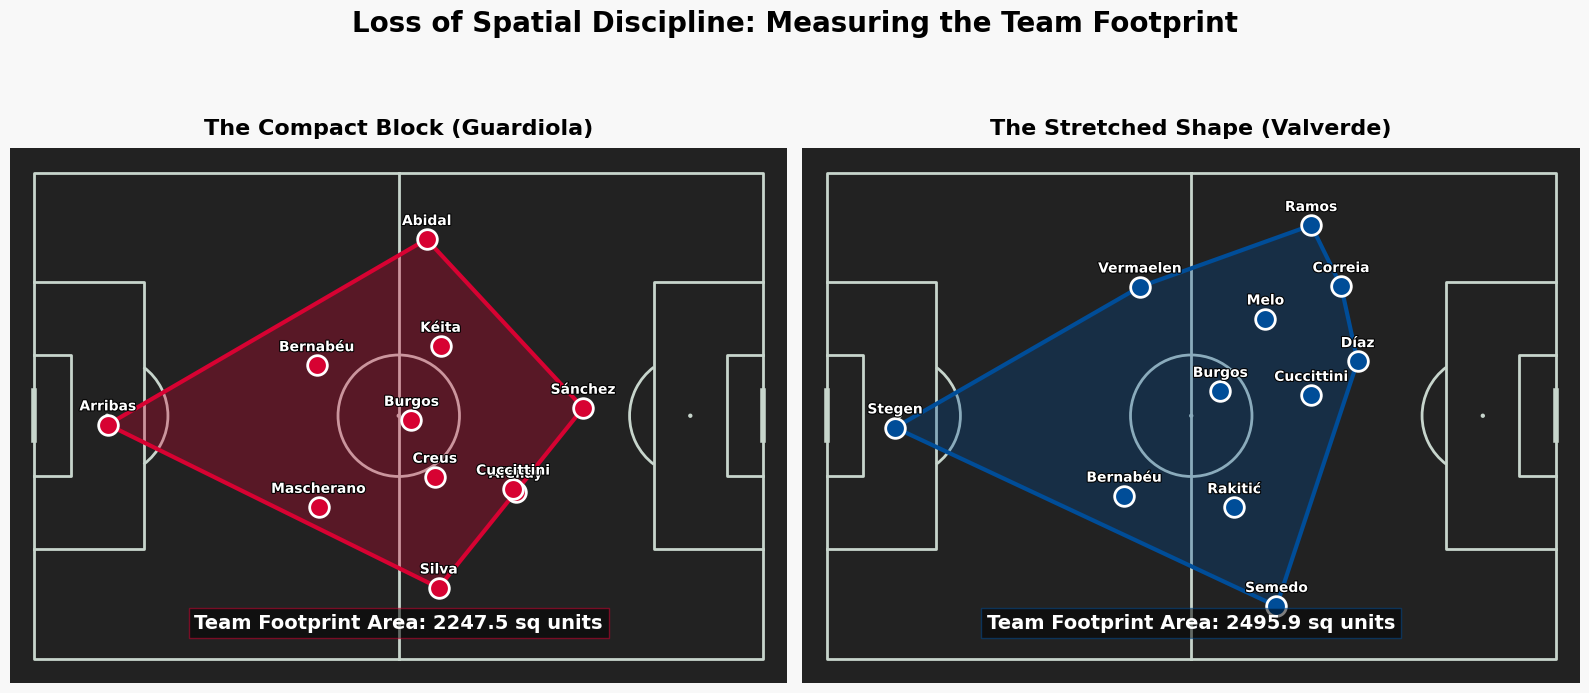

Convex Hulls successfully generated!


In [ ]:
# Cell 8: Team Compactness & Spatial Footprint
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from scipy.spatial import ConvexHull
import matplotlib.patheffects as pe

print("Calculating Spatial Compactness (Convex Hulls)...")

# 1. Load data
df = pd.read_pickle("barca_master_cleaned.pkl")

# Helper function to get a representative match
def get_representative_match(manager):
    manager_matches = df[(df['manager_era'] == manager) & (df['type'] == 'Pass') & (df['team'] == 'Barcelona')]
    match_counts = manager_matches.groupby('match_id').size()
    if match_counts.empty:
        return None
    return match_counts.idxmax()

match_pep = get_representative_match('Guardiola')
match_valverde = get_representative_match('Valverde')

def plot_convex_hull(match_id, ax, title, hull_color):
    if not match_id:
        ax.set_title(f"No data for {title}", fontsize=14)
        return
        
    match_events = df[(df['match_id'] == match_id) & (df['team'] == 'Barcelona')].copy()
    
    # Filter for passes before first sub to get Starting XI structure
    subs = match_events[match_events['type'] == 'Substitution']
    first_sub_min = subs['minute'].min() if not subs.empty else 90
    
    passes = match_events[(match_events['type'] == 'Pass') & (match_events['minute'] < first_sub_min)].copy()
    
    # Get top 11 players by pass volume
    top_11 = passes['player'].value_counts().head(11).index
    passes = passes[passes['player'].isin(top_11)]
    
    # Calculate average tactical position
    avg_locs = passes.groupby('player').agg(
        x=('location_x', 'mean'),
        y=('location_y', 'mean')
    ).reset_index()
    
    # --- DRAW PITCH ---
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#222222', line_color='#c7d5cc')
    pitch.draw(ax=ax)
    
    # --- CALCULATE & DRAW CONVEX HULL ---
    points = avg_locs[['x', 'y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        
        # Calculate Area (in StatsBomb units)
        area = hull.volume 
        
        for simplex in hull.simplices:
            pitch.plot(points[simplex, 0], points[simplex, 1], color=hull_color, lw=3, ax=ax, zorder=1)
            
        pitch.polygon([points[hull.vertices]], ax=ax, color=hull_color, alpha=0.3, zorder=1)
        
        # Display Area
        ax.text(60, 75, f"Team Footprint Area: {area:.1f} sq units", 
                color='white', fontsize=14, fontweight='bold', ha='center',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor=hull_color))

    # --- DRAW PLAYERS ---
    pitch.scatter(avg_locs['x'], avg_locs['y'], s=200, color=hull_color, edgecolors='white', lw=2, ax=ax, zorder=2)
    
    for _, row in avg_locs.iterrows():
        name = str(row['player']).split()[-1]
        pitch.annotate(name, xy=(row['x'], row['y'] - 3), c='white', va='center', ha='center', 
                       size=10, weight='bold', zorder=3, ax=ax,
                       path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])
        
    ax.set_title(title, fontsize=16, color='black', fontweight='bold', pad=10)

# 2. Plotting the graphic
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f8f8')

plot_convex_hull(match_pep, axes[0], "The Compact Block (Guardiola)", "#d70232")
plot_convex_hull(match_valverde, axes[1], "The Stretched Shape (Valverde)", "#004d98")

plt.suptitle("Loss of Spatial Discipline: Measuring the Team Footprint", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("Thesis_Fig_Convex_Hull.png", dpi=300, bbox_inches='tight')
plt.show()

print("Convex Hulls successfully generated!")

Training Random Forest Regressor to predict xGA based on tactical metrics...

Model Performance:
  Mean Squared Error (MSE): 0.2684
  R-squared (R2):           0.0407



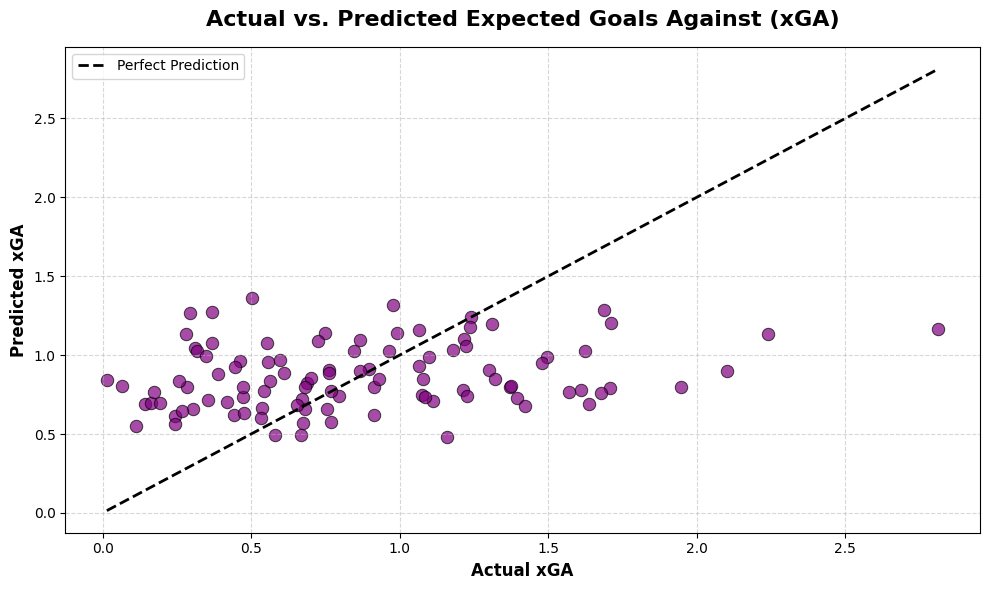

In [7]:
# Cell 9: Predictive Modeling - Random Forest Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Training Random Forest Regressor to predict xGA based on tactical metrics...\n")

# 1. Load Regression Data
# Ensure your CSV is located in the same directory as the notebook
df = pd.read_csv("barca_tactical_regression_data.csv")

# 2. Define Features (X) and Target (y)
features = [
    'ppda', 
    'defensive_line', 
    'convex_hull_area', 
    'high_turnover_pct', 
    'successful_passes'
]
target = 'xga'

# Drop missing values to ensure the model trains cleanly
df_clean = df.dropna(subset=features + [target])

X = df_clean[features]
y = df_clean[target]

# 3. Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = rf_model.predict(X_test)

# 6. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2):           {r2:.4f}\n")

# 7. Visualize Actual vs. Predicted xGA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', s=80, edgecolor='black')

# Add ideal 1-to-1 trendline for reference
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs. Predicted Expected Goals Against (xGA)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Actual xGA", fontsize=12, fontweight='bold')
plt.ylabel("Predicted xGA", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Thesis_Fig_RF_Actual_vs_Predicted.png", dpi=300, bbox_inches='tight')
plt.show()

Initializing SHAP TreeExplainer for the Random Forest Model...



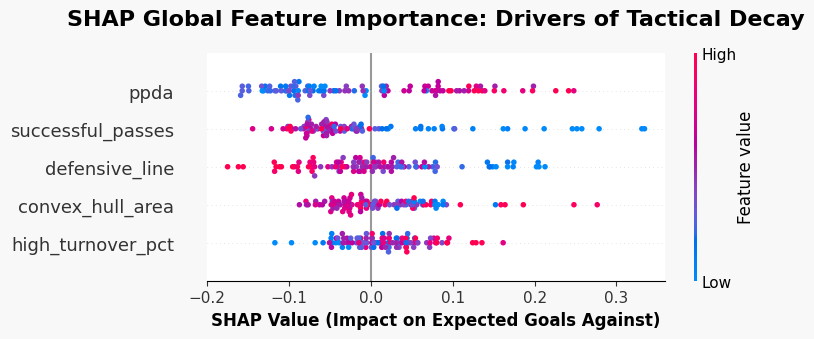


--- Micro-Case Study: Analyzing the Worst Defensive Match ---
Actual xGA for this match: 2.81


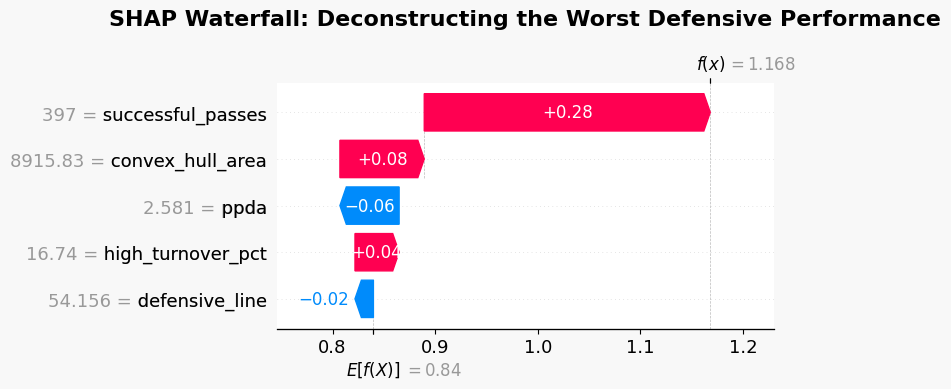

SHAP Game Theory Analysis complete! Thesis figures saved.


In [10]:
# Cell 10: Game Theory Integration (SHAP Analysis)
import shap
import matplotlib.pyplot as plt

print("Initializing SHAP TreeExplainer for the Random Forest Model...\n")

# 1. Initialize the SHAP Explainer using the Random Forest model from Cell 9
# (Ensure Cell 9 has been run so 'rf_model' and 'X_test' exist in memory)
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# 3. GLOBAL EXPLANATION: SHAP Summary Beeswarm Plot
# This proves which variables drove the defensive decay and in what direction.
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance: Drivers of Tactical Decay", fontsize=16, fontweight='bold', pad=20)

# The summary plot automatically generates its own figure, so we call it directly
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)

# Formatting the plot for the thesis
fig, ax = plt.gcf(), plt.gca()
fig.set_facecolor('#f8f8f8')
ax.set_xlabel("SHAP Value (Impact on Expected Goals Against)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("Thesis_Fig_SHAP_Global_Summary.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. LOCAL EXPLANATION: The "Disaster Match" Micro-Case Study
# Let's isolate the worst defensive performance in the test set to see exactly what went wrong
worst_match_idx = y_test.idxmax()
worst_match_xga = y_test.loc[worst_match_idx]

print(f"\n--- Micro-Case Study: Analyzing the Worst Defensive Match ---")
print(f"Actual xGA for this match: {worst_match_xga:.2f}")

# Generate a Waterfall plot to decompose this specific match's xGA
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall: Deconstructing the Worst Defensive Performance", fontsize=16, fontweight='bold', pad=20)

# Safely extract the base value (Expected Value) as a scalar float
base_val = explainer.expected_value
if hasattr(base_val, "__len__"):
    base_val = base_val[0]  # Extracts scalar if it's trapped in an array

# For waterfall plots, SHAP requires an Explanation object
# We use .values on the data to strip Pandas indexing and prevent dimension errors
exp = shap.Explanation(
    values=shap_values[X_test.index.get_loc(worst_match_idx)], 
    base_values=float(base_val), 
    data=X_test.loc[worst_match_idx].values, 
    feature_names=features
)

shap.plots.waterfall(exp, show=False)

fig = plt.gcf()
fig.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig("Thesis_Fig_SHAP_Worst_Match_Waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

print("SHAP Game Theory Analysis complete! Thesis figures saved.")